<a href="https://colab.research.google.com/github/AdamHopkinss/DD2365/blob/main/Current1_Project_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Euler equations for compressible flow**
**Johan Hoffman**

# **Abstract**

This short report show an example on how to use FEniCS to solve the Euler equations using FEM, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://www.kth.se/social/course/DD2365/)

# **About the code**

In [1]:
# This program is an example file for the course
# DD2365 Advanced Computation in Fluid Mechanics,
# KTH Royal Institute of Technology, Stockholm, Sweden,

# Copyright (C) 2021 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License v2.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

# **Set up environment**

In [2]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

The Euler equations take the form

$
\begin{eqnarray}
\dot \rho + \nabla \cdot (u \rho) = 0, \\
\dot m + \nabla \cdot (u m) + \nabla p = f, \\
\dot E + \nabla \cdot (u E) + \nabla \cdot(up)= 0,
\end{eqnarray}
$

together with suitable initial and boundary conditions.

Here velocity is given by

$u = \frac{m}{\rho},$

and for a perfect gas, the pressure is given by

$p = (\gamma - 1)(E-\frac{\vert u\vert^2}{2}),$

where $\gamma = 1.4$ is the specific heat ratio for air, and we get the temperature,

$T = \frac{E}{\rho} - \frac{\vert u\vert^2}{2},$

the speed of sound,

$\sqrt{\gamma(\gamma-1)T},$

and the Mach number,

$M = \frac{\vert u\vert }{c}.$

Here we present a FEniCS implementation of a stabilized finite element method to solve the Euler equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

# **Method**

**Define domain and mesh**

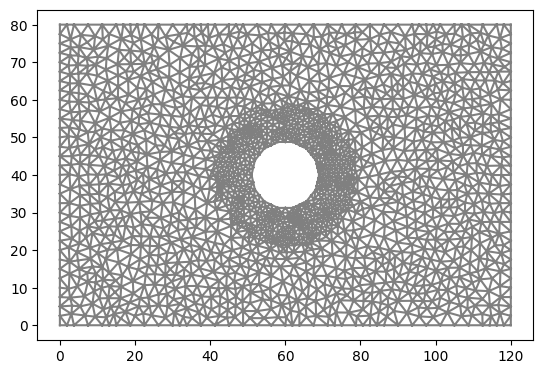

In [3]:
# Define rectangular domain
L = 120.0
H = 80.0

# Define circle
xc = 0.5*L
yc = 0.5*H
rc = 9

# Specific heat ratio for air
gamma = 1.4

# Generate mesh (examples with and without a hole in the mesh)
resolution = 32
#mesh = RectangleMesh(Point(0.0, 0.0), Point(L, H), L*resolution, H*resolution)
mesh = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - Circle(Point(xc,yc),rc), resolution)

# Local mesh refinement (specified by a cell marker)
no_levels = 1
for i in range(0,no_levels):
  cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
  for cell in cells(mesh):
    cell_marker[cell] = False
    p = cell.midpoint()
    if p.distance(Point(xc, yc)) < 2*rc:
        cell_marker[cell] = True
  mesh = refine(mesh, cell_marker)

# Define subdomains (for boundary conditions)
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], L)

class Lower(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0.0)

class Upper(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], H)

class Object(SubDomain):
    def inside(self, x, on_boundary, L=L, H=H):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

left = Left()
right = Right()
lower = Lower()
upper = Upper()
object = Object()

# Define mesh functions (for boundary conditions)
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundaries.set_all(0)
left.mark(boundaries, 1)
right.mark(boundaries, 2)
lower.mark(boundaries, 3)
upper.mark(boundaries, 4)
object.mark(boundaries, 5)

# Define measure for boundary integration
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

plt.figure()
plot(mesh)
plt.show()

### Defining the meteor

In [4]:
# Material density in kg/m³ (representing meteor compositions)
materials = {
    "iron": 7870.0,                      # iron meteor
    "ice": 917.0,                        # pure ice
    "stone": 3500.0,                     # rocky meteor
    "mixed": 0.6 * 7870.0 + 0.4 * 917.0  # 60% iron, 40% ice
}

# Select composition
material_choice = "iron"
object_density = materials[material_choice]

# Assumed depth of the 3D object (m)
object_depth = 1.0

# Compute area of the circular object (2D projection)
object_area = np.pi * rc**2  # m²

# Compute volume and mass
object_volume = object_area * object_depth  # m³
mass_object = object_density * object_volume  # kg

print(f"Material: {material_choice}, Mass: {mass_object/1000:.2f} tons")

Material: iron, Mass: 2002.67 tons


**Define finite element approximation spaces**

In [5]:
# Generate finite element spaces (for density, momentum, total energy)
R = FunctionSpace(mesh, "Lagrange", 1)
V = VectorFunctionSpace(mesh, "Lagrange", 1)
Q = FunctionSpace(mesh, "Lagrange", 1)

# Define trial and test functions
r = TrialFunction(R)
m = TrialFunction(V)
E = TrialFunction(Q)
d = TestFunction(R)
v = TestFunction(V)
q = TestFunction(Q)

### Inflow Model (Altitude-Dependent)
Atmospheric inflow quantities are updated dynamically using altitude $h$ (in meters) and current velocity $v(t)$:

#### Temperature:

A cubic fit clamped to avoid unphysical values:
\begin{align*}
T(h) = \max\left( -0.0016 \left( \frac{h}{1000} \right)^3 + 0.1905 \left( \frac{h}{1000} \right)^2 - 5.9628 \left( \frac{h}{1000} \right) + 277.3354, , 1 \right)
\end{align*}

#### Density:

Exponential decay model:
\begin{align*}
\rho(h) = 1.228 \cdot \exp\left( -0.1168 \cdot \frac{h}{1000} \right)
\end{align*}

#### Total Energy:

\begin{align*}
E(h, v) = \rho(h) \left( \frac{1}{2} v^2 + \frac{R T(h)}{\gamma - 1} \right)
\end{align*}
where $R = 287.05$ J/kg$\cdot$K and $\gamma = 1.4$

#### Velocity Update (Newton's Second Law):
\begin{align*}
v(t+\Delta t) = v(t) + \frac{mg - D(t)}{m} \cdot \Delta t
\end{align*}

#### Inflow Quantities:
\begin{align*}
m_{\text{in}} &= \rho(h) \cdot v(t) \\
E_{\text{in}} &= E(h, v(t))
\end{align*}

These are recomputed each step to reflect altitude and velocity changes.

In [6]:
def inflow_density(altitude):
    altitude_km = altitude / 1000
    rho_min = 1.0e-6
    return 1.228 * np.exp(-0.1168 * altitude_km)

def inflow_temperature(altitude):
    # h is in meters, convert to km
    # Fitted model using Matlab and Wikipedia values for standard Atmosphere
    altitude_km = altitude / 1000
    return max(-0.0016 * altitude_km**3 + 0.1905 * altitude_km**2 - 5.9628 * altitude_km + 277.3354, 100)  # cut off for solver stability


def inflow_energy(altitude, velocity):      # Dependent on inflow velo. and altitude
    rho = inflow_density(altitude)
    T = inflow_temperature(altitude)
    return rho * (0.5 * velocity**2 + 287.05 * T / (gamma - 1))


**Define boundary conditions**

In [7]:
# Define boundary conditions
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary, H=H):
        return on_boundary and near(x[1], H)

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary, L=L):
        return on_boundary and near(x[0], L)

class DirichletBoundaryObjects(SubDomain):
    def inside(self, x, on_boundary, L=L, H=H):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()
dbc_objects = DirichletBoundaryObjects()

dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()
dbc_objects = DirichletBoundaryObjects()

# Inflow variables (will be changed in time-stepping loop)
m_in = Constant(0.0)
r_in = Constant(1.0)
E_in = Constant(1.0)
m_in_vec = as_vector([m_in, 0.0])

bcm_in0 = DirichletBC(V.sub(0), m_in, dbc_left)
bcm_in1 = DirichletBC(V.sub(1), 0.0, dbc_left)
bcm_upp0 = DirichletBC(V.sub(0), 0.0, dbc_upper)
bcm_upp1 = DirichletBC(V.sub(1), 0.0, dbc_upper)
bcm_low0 = DirichletBC(V.sub(0), 0.0, dbc_lower)
bcm_low1 = DirichletBC(V.sub(1), 0.0, dbc_lower)


bcr_in = DirichletBC(R, r_in, dbc_left)
bcE_in = DirichletBC(Q, E_in, dbc_left)

bcm = [bcm_in0, bcm_in1, bcm_upp0, bcm_upp1, bcm_low0, bcm_low1]
bcr = [bcr_in]
bcE = [bcE_in]

# **Results**

**Define method parameters**

In [8]:
# Define iteration functions
# *0 solution from previous time step
# *1 linearized solution at present time step
r0 = Function(R)
m0 = Function(V)
E0 = Function(Q)
r1 = Function(R)
m1 = Function(V)
E1 = Function(Q)

eps_cav = Constant(1.0e-8)

# Set parameters for nonlinear and linear solvers
num_nnlin_iter = 10
prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

# Time step length
# dt = 0.5*mesh.hmin()*(r_in/m_in)
dt = Constant(0.001)  # initial guess, will change in loop to follow CFL type condition

**Define variational problem**

### Adaptive Stabilization Parameters

We scale key stabilization terms with the local Mach number $\mathrm{Ma}$ to improve robustness across flow regimes:

- **SUPG stabilization:**
  $$
  C_1(\mathrm{Ma}) = 0.5 + 4.5 \cdot \frac{\mathrm{Ma}^2}{1 + \mathrm{Ma}^2}
  $$
  Smoothly increases from 0.5 (incompressible) to 5 (hypersonic), used in time/space stabilization.

- **Artificial viscosity:**
  $$
  C_{\text{stab}}(\mathrm{Ma}) = 1 + 15 \cdot \frac{\mathrm{Ma}}{1 + \mathrm{Ma}}
  $$
  Rises from 1 to ~16 to stabilize shocks via residual-based diffusion.

- **Penalty parameter:**
  $$
  C_\alpha(\mathrm{Ma}) = 50 + 750 \cdot \frac{\mathrm{Ma}}{1 + \mathrm{Ma}}
  $$
  Ramps from 50 to 800, strengthening boundary enforcement at higher speeds.


In [9]:
# Define variational problem

# Mean velocities for trapozoidal time stepping
rm = 0.5*(r + r0)
mm = 0.5*(m + m0)
Em = 0.5*(E + E0)

rm1 = 0.5*(r1 + r0)
mm1 = 0.5*(m1 + m0)
Em1 = 0.5*(E1 + E0)

u0 = m0/(r0 + eps_cav)
u1 = m1/(r1 + eps_cav)
um1 = 0.5*(u1 + u0)

# Perfect gas
#gamma = 1.4 # specific heat ratio for air
# Pressure
p1 = (gamma - 1.0)*(E1 - 0.5*inner(m1,m1)/(r1 + eps_cav))

# Temperature
Temp = E1/(r1 + eps_cav) - 0.5*inner(u1, u1)


# Speed of sound
c = sqrt(gamma*(gamma-1.0)*Temp)

# Mach number
Mach = sqrt(inner(u1, u1))/c

# Facet normal
normal = FacetNormal(mesh)

# Local mesh size
h = CellDiameter(mesh);

# Stabilization parameters
u_mag = sqrt(dot(u1,u1))
# C1 = 0.5
from ufl_legacy import max_value, min_value
C1 = 0.5 + 4.5 * (Mach**2 / (1 + Mach**2))
d1 = C1 / (sqrt(1.0/dt**2 + max_value(u_mag, 10.0)**2/h**2)) # Streamline-upwind (SUPG)-like stabilization

# Penalty boundary conditions
# C_alpha = 1.0e2
C_alpha = 50 + 750 * (Mach / (1 + Mach))  # smoothly ramps
alpha = C_alpha/h

# Residuals
res_r = (rm1 - r0)/dt + div(u1)*r1 + inner(grad(r1), u1)
res_m = (mm1 - m0)/dt + div(u1)*m1 + grad(m1)*u1 + grad(p1)

# Improved energy residual (removed redundant pressure terms)
flux_E = E1 * u1 + p1 * u1
res_E = (Em1 - E0)/dt + div(flux_E)

# Smagorinsky model (simplified)
C_t = 1.0e-2

# Shock sensor based on energy variation (Persson–Peraire-like)
V_dg = FunctionSpace(mesh, 'DG', 0)

# Project the gradient magnitude of E1
grad_E1 = project(sqrt(inner(grad(E1), grad(E1))), V_dg)

# Project E1 into DG space for stable normalization
E1_dg = project(E1, V_dg)

# Compute shock sensor value: |∇E| / E
sensor_expr = grad_E1 / (E1_dg + 1e-8)
sensor_E = project(sensor_expr, V_dg)

# Clip overly large sensor values (optional safety)
sensor_E.vector().set_local(np.minimum(sensor_E.vector().get_local(), 100.0))

# Smooth cutoff: sensor / (1 + sensor)
cutoff_expr = sensor_E / (sensor_E + 1.0)
sensor_cut = project(cutoff_expr, V_dg)  # smooth activation of viscosity

# Mach-adaptive viscosity constant (same as before)
C_stab = 1.0 + 15 * (Mach / (1 + Mach))

# Local artificial viscosity (only where shock sensor is active)
nu_r = C_stab * h**2 * sqrt(res_r**2) / r_in * sensor_cut
nu_m = C_stab * h**2 * sqrt(inner(res_m, res_m)) / m_in * sensor_cut
nu_E = C_stab * h**2 * sqrt(res_E**2) / E_in * sensor_cut


# Density variational equation on residual form
Fr = inner((r - r0)/dt, d)*dx - inner(rm*um1, grad(d))*dx \
    + nu_r * inner(grad(rm), grad(d))*dx \
    + inner(dot(um1, normal)*r_in, d)*ds(1) \
    + inner(dot(um1, normal)*rm, d)*ds(2) \
    + d1*inner((r - r0)/dt + div(u1)*rm + inner(grad(rm), u1), dot(grad(d), u1))*dx

ar = lhs(Fr)
Lr = rhs(Fr)

# Momentum variational equation on residual form
Fm = inner((m - m0)/dt, v)*dx - inner(outer(mm,um1), grad(v))*dx - p1*div(v)*dx \
        + nu_m * inner(grad(mm), grad(v))*dx \
        + alpha*(inner(dot(mm,normal), dot(v,normal)))*ds(5) \
        + (dot(u1, normal)*inner(m_in_vec, v))*ds(1) \
        + (dot(u1, normal)*inner(mm, v))*ds(2) \
        + d1*inner((m - m0)/dt + div(u1)*mm + grad(mm)*u1 + grad(p1), grad(v)*u1)*dx

am = lhs(Fm)
Lm = rhs(Fm)

# Density variational equation on residual form
FE = inner((E - E0)/dt, q)*dx - inner(Em*um1, grad(q))*dx \
    + nu_E * inner(grad(Em), grad(q))*dx \
    + inner(dot(um1, normal)*E_in, q)*ds(1) \
    + inner(dot(um1, normal)*Em, q)*ds(2) \
    + d1*inner((E - E0)/dt + div(flux_E), dot(grad(q), u1))*dx

aE = lhs(FE)
LE = rhs(FE)

**Compute force on boundary**

In [10]:
# Define the direction of the force to be computed
psi_x = 1.0
psi_y = 0.0

# Define the indicator function for the force
V_psi = VectorFunctionSpace(mesh, "CG", 1)
psi = Function(V_psi)
psi.vector()[:] = 0.0

bc_psi = DirichletBC(V_psi, Constant((psi_x, psi_y)), dbc_objects)
bc_psi.apply(psi.vector())

# Velocity
u1 = m1/(r1 + eps_cav)

# Force = inner((u1 - u0)/dt + grad(um1)*um1, psi)*dx - p1*div(psi)*dx
# Force = inner((m1 - m0)/dt + div(u1)*m1 + grad(m1)*u1, psi)*dx - p1*div(psi)*dx

force_normal = FacetNormal(mesh)
Force_pressure = inner(force_normal, psi)*p1*ds(5)

# Force normalization to get non-dimensional force coefficient (e.g. cd)
#D = 2*rc
u_in = m_in/r_in
normalization = -2.0/(2.0*rc*u_in*u_in)
#normalization = 1.0

**Set plotting variables and open export files**

In [11]:
# Open files to export solution to Paraview
file_r = File("results-NS/r.pvd")
file_m = File("results-NS/m.pvd")
file_E = File("results-NS/E.pvd")
file_Mach = File("results-NS/Mach.pvd")

# Set plot frequency
plot_time = 0
plot_freq = 50

# Force computation data
force_array = np.array(0.0)
force_array = np.delete(force_array, 0)

force_array_pressure = np.array(0.0)
force_array_pressure = np.delete(force_array_pressure, 0)

time = np.array(0.0)
time = np.delete(time, 0)

start_sample_time = 1.0

### Time stepping algorithm

#### Simulating for Initial Conditions (IC)

rm: cannot remove 'results-NS/*': No such file or directory
[INFO] h = 40000.0 m, rho = 1.1486e-02, E = 1.9889e+03, p = 6.9243e+04, v = 10.00 m/s, T = 241.2 K
Energy in = 1.9889e+03, Density in = 1.14862e-02, Momentum in = 1.1486e-01


RuntimeError: 

*** -------------------------------------------------------------------------
*** DOLFIN encountered an error. If you are not able to resolve this issue
*** using the information listed below, you can ask for help at
***
***     https://fenicsproject.discourse.group/
***
*** Remember to include the error message listed below and, if possible,
*** include a *minimal* running example to reproduce the error.
***
*** -------------------------------------------------------------------------
*** Error:   Unable to solve linear system using PETSc Krylov solver.
*** Reason:  Solution failed to converge in 0 iterations (PETSc reason DIVERGED_NANORINF, residual norm ||r|| = -nan).
*** Where:   This error was encountered inside PETScKrylovSolver.cpp.
*** Process: 0
*** 
*** DOLFIN version: 2019.2.0.dev0
*** Git changeset:  d510ebc53c73915f4f1f02ae8432b5c389c44df7
*** -------------------------------------------------------------------------


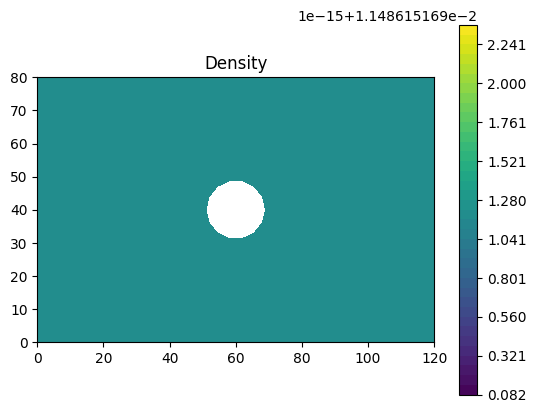

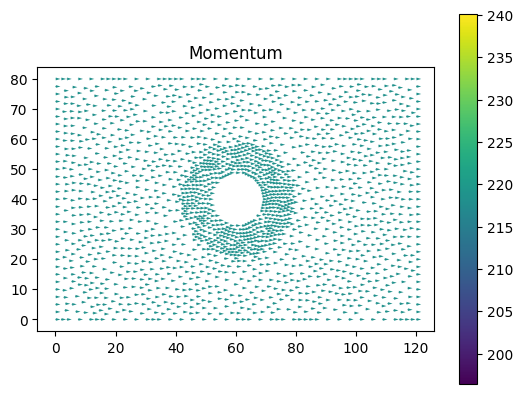

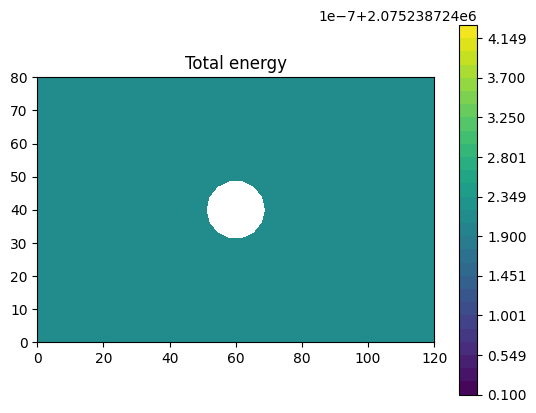

In [12]:
!rm results-NS/*
# Set minimum values
rho_min = 1e-6
E_min = 1e-6

# Initial altitude and velocity
altitude = 40000.0           # m (85 km altitude)
target_altitude = 30000.0     # m (30 km, simaluation target)
target_velocity = 19000            # m/s initial velocity
mass_object = mass_object     # kg, defined earlier
g = 9.81                      # m/s²

# Initialize inflow quantities
rho_init = inflow_density(altitude)
E_init = inflow_energy(altitude, target_velocity)

r0.interpolate(Constant(rho_init))
m0.interpolate(Constant((rho_init * target_velocity, 0.0)))
E0.interpolate(Constant(E_init))

# Plot solution
plt.figure()
im = plot(r0, title="Density")
plt.colorbar(im)

plt.figure()
im = plot(m0, title="Momentum")
plt.colorbar(im)

plt.figure()
im = plot(E0, title="Total energy")
plt.colorbar(im)

# To update dt using CFL type condition
def update_dt(velocity):
  cfl = 0.5
  return Constant(cfl * mesh.hmin() / (velocity + 1e-8))

# Loop to ramp up to the starting velocity
ramp_velocity = 10
ramping = 10
dt = update_dt(ramp_velocity)
t = float(dt)

while ramp_velocity < target_velocity:
    # Update inflow
    rho_inflow = inflow_density(altitude)
    E_inflow = inflow_energy(altitude, ramp_velocity)

    m_in.assign(rho_inflow * ramp_velocity)
    r_in.assign(rho_inflow)
    E_in.assign(E_inflow)

    # Check values
    rho_val = float(r_in)
    E_val = float(E_in)
    u_val = float(m_in) / (rho_val + 1e-8)
    T_val = inflow_temperature(altitude)
    p_val = (gamma - 1.0) * (E_val / rho_val - 0.5 * u_val**2)

    print(f"[INFO] h = {altitude:.1f} m, rho = {rho_val:.4e}, E = {E_val:.4e}, p = {p_val:.4e}, v = {u_val:.2f} m/s, T = {T_val:.1f} K")

    # Update time step dt
    dt.assign(update_dt(ramp_velocity))
    current_dt = float(dt)
    print(f"Energy in = {float(E_in):.4e}, Density in = {float(r_in):.5e}, Momentum in = {float(m_in):.4e}")

    # --- Initialize solution for Newton iteration ---
    r1.assign(r0)
    m1.assign(m0)
    E1.assign(E0)

    # Solve non-linear problem
    k = 0
    while k < num_nnlin_iter:
        # Skip shock sensor on first iteration
        if k == 0:
            sensor_cut.assign(project(Constant(0.0), V_dg))

        # Check for NaNs in variables
        if np.any(np.isnan(r1.vector().get_local())) or np.any(np.isnan(E1.vector().get_local())) or np.any(np.isnan(m1.vector().get_local())):
            print("[ERROR] NaN detected in solution variables. Stopping iteration.")
            break

        # Assemble and solve for density
        Ar = assemble(ar)
        br = assemble(Lr)
        [bc.apply(Ar, br) for bc in bcr]
        [bc.apply(r1.vector()) for bc in bcr]
        solve(Ar, r1.vector(), br, "bicgstab", "default")

        # Assemble and solve for momentum
        Am = assemble(am)
        bm = assemble(Lm)
        [bc.apply(Am, bm) for bc in bcm]
        [bc.apply(m1.vector()) for bc in bcm]
        solve(Am, m1.vector(), bm, "bicgstab", "default")

        # Assemble and solve for energy
        AE = assemble(aE)
        bE = assemble(LE)
        [bc.apply(AE, bE) for bc in bcE]
        [bc.apply(E1.vector()) for bc in bcE]
        solve(AE, E1.vector(), bE, "bicgstab", "default")

        # Compute force
        D = assemble(Force_pressure)

        # Clamp unphysical values
        r1.vector().set_local(np.maximum(r1.vector().get_local(), rho_min))
        E1.vector().set_local(np.maximum(E1.vector().get_local(), E_min))
        E1.vector().set_local(np.minimum(E1.vector().get_local(), 1e6))  # Optional max clamp

        # Recompute shock sensor after energy update
        grad_E1 = project(sqrt(inner(grad(E1), grad(E1))), V_dg)
        E1_dg = project(E1, V_dg)
        sensor_expr = grad_E1 / (E1_dg + 1e-8)
        sensor_E = project(sensor_expr, V_dg)
        sensor_E.vector().set_local(np.minimum(sensor_E.vector().get_local(), 100.0))
        cutoff_expr = sensor_E / (sensor_E + 1.0)
        sensor_cut = project(cutoff_expr, V_dg)

        # Under-relaxation (Newton damping)
        omega = 0.3
        r1.vector()[:] = (1 - omega)*r0.vector() + omega*r1.vector()
        m1.vector()[:] = (1 - omega)*m0.vector() + omega*m1.vector()
        E1.vector()[:] = (1 - omega)*E0.vector() + omega*E1.vector()

        k += 1

    # end non-linear problem solver
    print(f"t = {float(t):.2f}s, dt = {current_dt:.5f}s, altitude = {altitude:.1f} m, velocity = {ramp_velocity:.2f} m/s, drag = {D:.2f} N")

    # Update velocity
    ramp_velocity += ramping * current_dt

    # Update time step and state
    r0.assign(r1)
    m0.assign(m1)
    E0.assign(E1)
    t += current_dt


velocity = ramp_velocity



### Main Simulation with calculated IC

In [ ]:
# Time stepping
T = 20
while altitude > target_altitude:
  # Update inflow
  rho_inflow = inflow_density(altitude)
  E_inflow = inflow_energy(altitude, velocity)

  m_in.assign(rho_inflow * velocity)
  r_in.assign(rho_inflow)
  E_in.assign(E_inflow)

  # Update time step dt
  dt.assign(update_dt(velocity))
  current_dt = float(dt)

  # Catch non-physical states (negative energy etc.)
  if r0.vector().min() <= 0 or E0.vector().min() <= 0:
    print("Nonphysical initial state. Stopping iteration.")
    break

  # Solve non-linear problem
  k = 0
  while k < num_nnlin_iter:

    # Assemble density matrix and vector
    Ar = assemble(ar)
    br = assemble(Lr)

    # Compute density solution
    [bc.apply(Ar, br) for bc in bcr]
    [bc.apply(r1.vector()) for bc in bcr]
    solve(Ar, r1.vector(), br, "bicgstab", "default")

    # Assemble momentum matrix and vector
    Am = assemble(am)
    bm = assemble(Lm)

    # Compute momentum solution
    [bc.apply(Am, bm) for bc in bcm]
    [bc.apply(m1.vector()) for bc in bcm]
    solve(Am, m1.vector(), bm, "bicgstab", "default")

    # Slip boundary condition
    #bcm_slip_0 = m1[0] - dot(m1, node_normal)*node_normal[0]
    #bcm_slip_1 = m1[1] - dot(m1, node_normal)*node_normal[1]
    #[bc.apply(m1.vector()) for bc in bcm_slip]

    # Assemble total energy matrix and vector
    AE = assemble(aE)
    bE = assemble(LE)

    # Compute total energy solution
    [bc.apply(AE, bE) for bc in bcE]
    [bc.apply(E1.vector()) for bc in bcE]
    solve(AE, E1.vector(), bE, "bicgstab", "default")

    # Compute force
    D = assemble(Force_pressure)

    # Clamp unphysical values
    r1.vector().set_local(np.maximum(r1.vector().get_local(), rho_min))
    E1.vector().set_local(np.maximum(E1.vector().get_local(), E_min))
    E1.vector().set_local(np.minimum(E1.vector().get_local(), 1e6))  # Optional max clamp

    # --- Recompute shock sensor after energy update ---
    grad_E1 = project(sqrt(inner(grad(E1), grad(E1))), V_dg)
    E1_dg = project(E1, V_dg)
    sensor_expr = grad_E1 / (E1_dg + 1e-8)
    sensor_E = project(sensor_expr, V_dg)
    sensor_E.vector().set_local(np.minimum(sensor_E.vector().get_local(), 100.0))

    cutoff_expr = sensor_E / (sensor_E + 1.0)
    sensor_cut = project(cutoff_expr, V_dg)


    # Under-relaxation (Newton damping)
    omega = 0.3
    r1.vector()[:] = (1 - omega)*r0.vector() + omega*r1.vector()
    m1.vector()[:] = (1 - omega)*m0.vector() + omega*m1.vector()
    E1.vector()[:] = (1 - omega)*E0.vector() + omega*E1.vector()


    k += 1
    # end non-linear problem solver
  # Update velocity using Newton II law: a = (mg - D)/m
  D = float(assemble(Force_pressure))
  acceleration = (mass_object * g - D) / mass_object
  velocity = velocity + acceleration * current_dt
  # Update altitude
  altitude -= velocity * current_dt + 0.5 * acceleration * current_dt**2

  # Print out relevant info
  print(f"t = {float(t):.2f}s, dt = {current_dt:.5f}s, altitude = {altitude:.1f} m, velocity = {velocity:.2f} m/s, drag = {D:.2f} N")

  if t > plot_time:

    s = 'Time t = ' + repr(t)
    print(s)

    u1 = m1 / (r1 + eps_cav)
    Temp = E1/(r1 + eps_cav) - 0.5*inner(u1, u1)
    c = sqrt(gamma*(gamma-1.0)*abs(Temp))
    Mach_number = project(sqrt(inner(u1, u1))/(c + eps_cav), Q)

    # Save solution to file
    file_r << r1
    file_m << m1
    file_E << E1
    file_Mach << Mach_number

    # Plot solution
    plt.figure()
    im = plot(r1, title="Density")
    plt.colorbar(im)

    plt.figure()
    im = plot(m1, title="Momentum")
    plt.colorbar(im)

    plt.figure()
    im = plot(E1, title="Total energy")
    plt.colorbar(im)

    plt.figure()
    im = plot(u1, title="Velocity")
    plt.colorbar(im)

    plt.figure()
    im = plot(sqrt(inner(u1, u1)), title="Velocity magnitude")
    plt.colorbar(im)

    plt.figure()
    im = plot(Mach_number, title="Mach number")
    plt.colorbar(im)

    plt.figure()
    im = plot(Temp, title="Temperature")
    plt.colorbar(im)

    plot_time += T/plot_freq

    plt.show()

  # Update time step
  r0.assign(r1)
  m0.assign(m1)
  E0.assign(E1)
  t += current_dt

In [ ]:

# !tar -czvf results-NS.tar.gz results-NS
# files.download('results-NS.tar.gz')
# Project p1 to a function space so we can inspect values
p1_proj = project(p1, Q)

# Check for NaNs or negative values
p_vals = p1_proj.vector().get_local()


# **Discussion**

A stabilized finite element method was implemented in FEniCS to solve the Euler equations for compressible flow in 2D.